# Zomato Restaurant Data Analysis

## Introduction

The objective of this project is to analyze the Zomato restaurant dataset and identify patterns related to restaurant ratings, cuisines, pricing, and locations through data cleaning and exploratory data analysis.

## Dataset Loading

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhanupratapbiswas/zomato")

print("Path to dataset files:", path)

100%|██████████| 5.28M/5.28M [00:01<00:00, 3.99MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bhanupratapbiswas/zomato/versions/1


In [2]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(file)

zomato.csv


In [3]:
import pandas as pd

df = pd.read_csv(
    "/root/.cache/kagglehub/datasets/bhanupratapbiswas/zomato/versions/1/zomato.csv"
)

df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


## Data Cleaning

In [4]:
df.shape

(56252, 13)

In [5]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [7]:
df.isnull().sum()

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


In [8]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

,0
dish_liked,50.175994
rate,13.933727
listed_in(type),8.195264
phone,2.303918
approx_cost(for two people),0.926189
rest_type,0.600868
cuisines,0.360876
location,0.223992
votes,0.138662
book_table,0.103107


In [9]:
df['rate'].unique()[:20]

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5',
       '\\nTop floor', '4.2/5', '3.9/5', '3.1/5', '3.0/5', '3.2/5',
       '3.3/5', '2.8/5', " ('Rated 1.0'", " ('Rated 5.0'", '4.4/5',
       ' always a good experience',
       ' a mocktail and did i just hear unlimited desserts?!\\nGoodbye midweek blues!!!?\\n\\nI would specially mention the staff here-Chaitanya',
       '4.3/5'], dtype=object)

In [10]:
df['rate'].unique()[:20]

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5',
       '\\nTop floor', '4.2/5', '3.9/5', '3.1/5', '3.0/5', '3.2/5',
       '3.3/5', '2.8/5', " ('Rated 1.0'", " ('Rated 5.0'", '4.4/5',
       ' always a good experience',
       ' a mocktail and did i just hear unlimited desserts?!\\nGoodbye midweek blues!!!?\\n\\nI would specially mention the staff here-Chaitanya',
       '4.3/5'], dtype=object)

In [11]:
df['rate'].sample(20)

,rate
42544,3.5 /5
12092,3.3/5
6630,3.7/5
20630,4.1/5
5365,3.9/5
39790,NEW
15015,4.0/5
588,4.2/5
8901,3.5/5
50486,NaN


In [12]:
df['rate'].sample(20)

,rate
27869,pesto they use is coriander ( they will infor...
9653,4.1/5
16213,3.3/5
50717,"""""RATED\n Really good ice creams . They have..."
31295,4.3 /5
47330,3.8 /5
10186,NaN
15168,NaN
8862,3.8/5
23559,3.6/5


In [13]:
df['rate'].nunique()

2877

In [14]:
import numpy as np

df['clean_rate'] = (
    df['rate']
    .astype(str)
    .str.extract(r'(\d+\.\d+)')[0]
)

df['clean_rate'] = pd.to_numeric(
    df['clean_rate'],
    errors='coerce'
)

df[['rate', 'clean_rate']].head(20)

,rate,clean_rate
0,4.1/5,4.1
1,4.1/5,4.1
2,3.8/5,3.8
3,3.7/5,3.7
4,3.8/5,3.8
5,3.8/5,3.8
6,3.6/5,3.6
7,4.6/5,4.6
8,4.0/5,4.0
9,\nTop floor,NaN


In [15]:
import pandas as pd
import numpy as np

df['clean_rate'] = (
    df['rate']
    .astype(str)
    .str.extract(r'(\d+\.\d+)')[0]
)

df['clean_rate'] = pd.to_numeric(
    df['clean_rate'],
    errors='coerce'
)

In [16]:
df[['rate', 'clean_rate']].sample(15)

,rate,clean_rate
15310,3.1/5,3.1
2854,3.2/5,3.2
51413,2.9 /5,2.9
17420,3.8/5,3.8
53657,3.0 /5,3.0
29181,4.2/5,4.2
14488,NaN,NaN
33974,3.7 /5,3.7
51276,4.0 /5,4.0
17681,3.1/5,3.1


In [17]:
df['clean_rate'].describe()

,clean_rate
count,42948.000000
mean,3.703072
std,0.476952
min,0.500000
25%,3.400000
50%,3.700000
75%,4.000000
max,5.000000


## Exploratory Data Analysis

## Visualizations

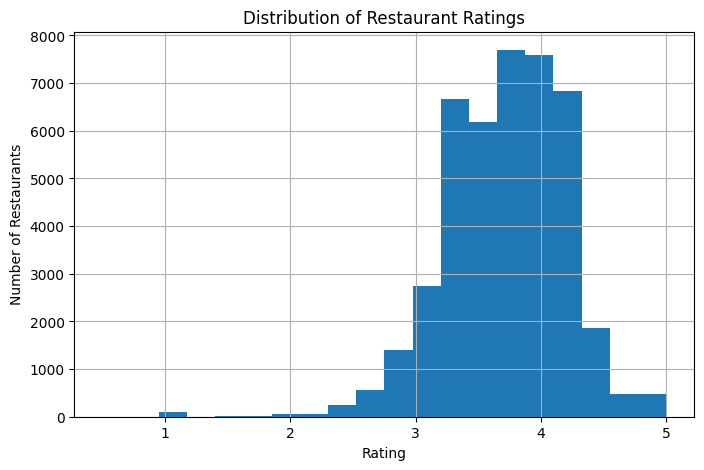

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['clean_rate'].hist(bins=20)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')

plt.show()

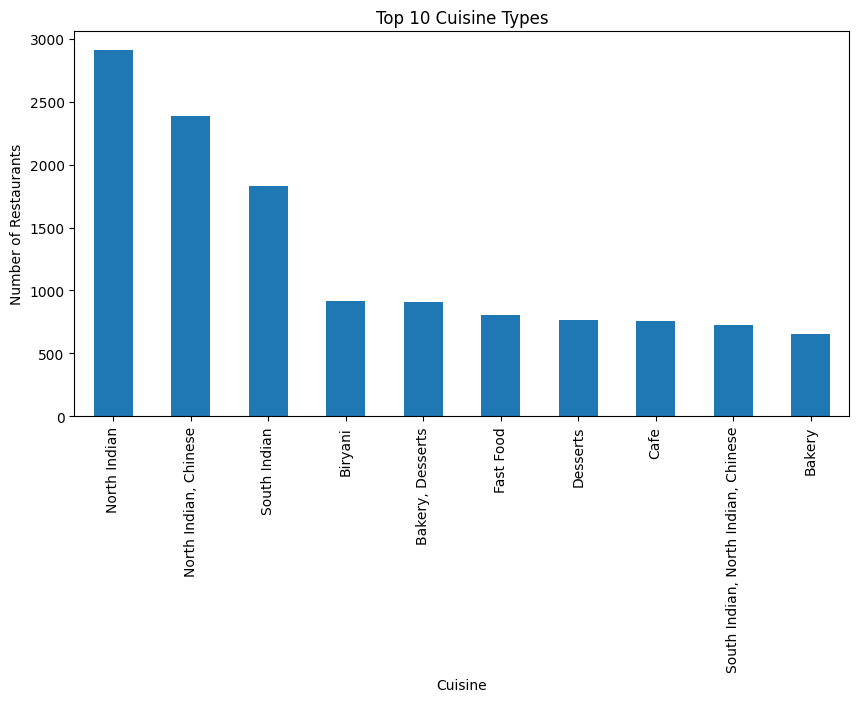

In [19]:
top_cuisines = (
    df['cuisines']
    .value_counts()
    .head(10)
)

top_cuisines.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Cuisine Types')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')

plt.show()

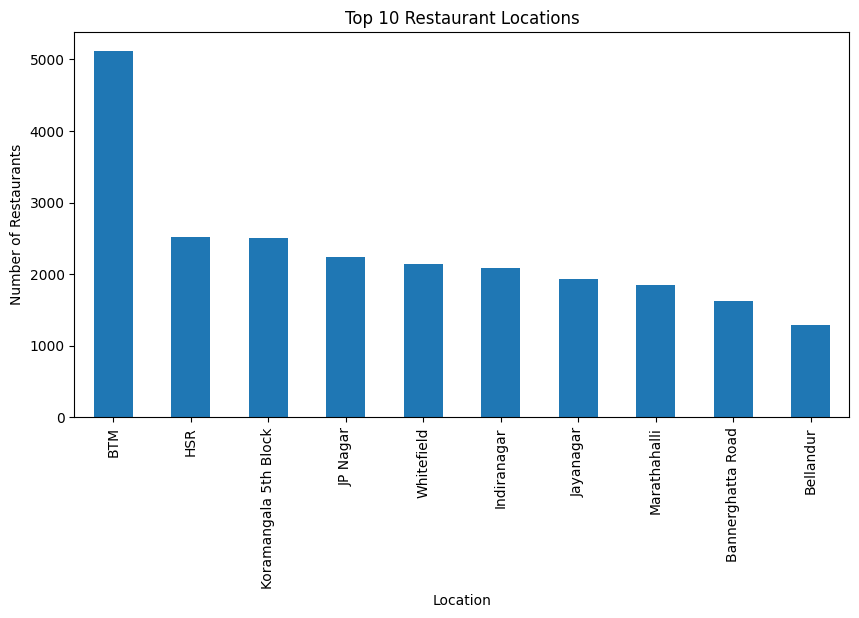

In [20]:
import matplotlib.pyplot as plt

top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_locations.plot(kind='bar')

plt.title('Top 10 Restaurant Locations')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')

plt.show()

In [21]:
df['approx_cost(for two people)'].sample(20)

,approx_cost(for two people)
24938,300
18842,300
51453,150
48683,NaN
18915,700
53552,"1,000"
24667,"1,600"
14788,300
47604,'RATED\n The aqua environment is to good and...
38469,300


In [22]:
df['clean_cost'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)')[0]
)

df['clean_cost'] = pd.to_numeric(
    df['clean_cost'],
    errors='coerce'
)

In [23]:
df[['approx_cost(for two people)', 'clean_cost']].sample(15)

,approx_cost(for two people),clean_cost
29130,600,600.0
8951,400,400.0
5642,600,600.0
40869,"1,000",1000.0
34825,400,400.0
48827,500,500.0
28973,900,900.0
22799,250,250.0
43703,"2,000",2000.0
38903,200,200.0


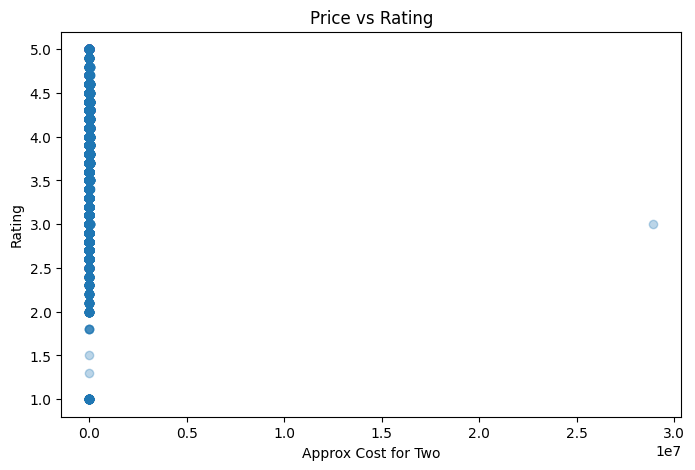

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['clean_cost'],
    df['clean_rate'],
    alpha=0.3
)

plt.title('Price vs Rating')
plt.xlabel('Approx Cost for Two')
plt.ylabel('Rating')

plt.show()

In [25]:
df['clean_cost'].describe()

,clean_cost
count,5.316900e+04
mean,1.081347e+03
std,1.253823e+05
min,0.000000e+00
25%,3.000000e+02
50%,4.000000e+02
75%,6.500000e+02
max,2.891152e+07


In [26]:
df.nlargest(
    10,
    'clean_cost'
)[[
    'approx_cost(for two people)',
    'clean_cost'
]]

,approx_cost(for two people),clean_cost
53994,"""""RATED\n I had visited la Casa before they ...",28911524.0
20404,"6,000",6000.0
49482,"6,000",6000.0
43481,"5,000",5000.0
44933,"4,500",4500.0
45523,"4,500",4500.0
40641,"4,100",4100.0
42245,"4,100",4100.0
42581,"4,100",4100.0
43477,"4,100",4100.0


In [27]:
df = df[df['clean_cost'] < 10000]

In [28]:
df['clean_cost'].describe()

,clean_cost
count,53168.000000
mean,537.590637
std,442.427606
min,0.000000
25%,300.000000
50%,400.000000
75%,650.000000
max,6000.000000


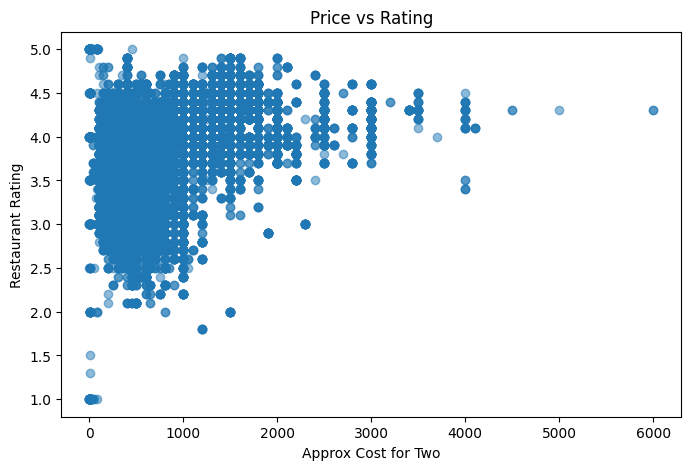

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df['clean_cost'],
    df['clean_rate'],
    alpha=0.5
)

plt.xlabel("Approx Cost for Two")
plt.ylabel("Restaurant Rating")
plt.title("Price vs Rating")

plt.show()

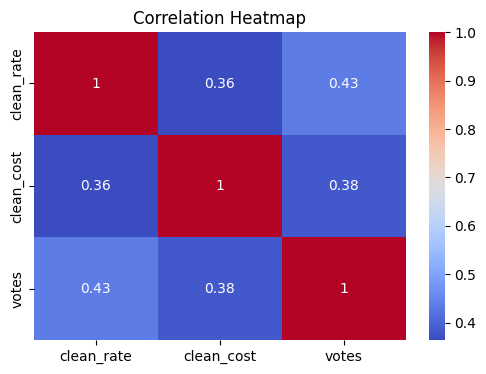

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_data = df[['clean_rate', 'clean_cost', 'votes']].copy()

corr_data['votes'] = pd.to_numeric(
    corr_data['votes'],
    errors='coerce'
)

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

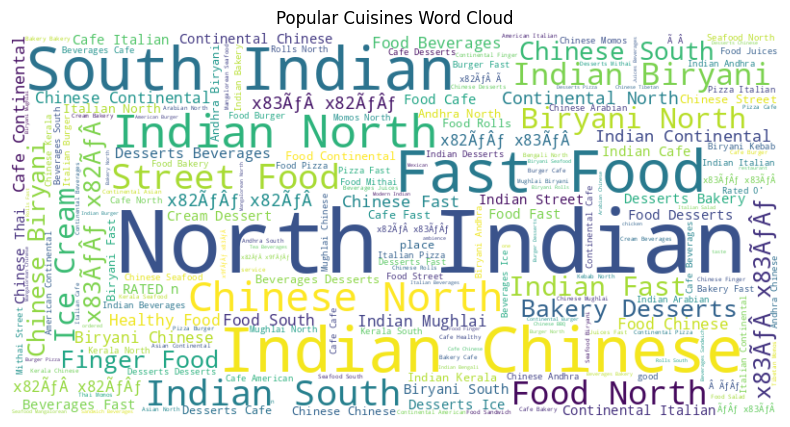

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(
    df['cuisines']
    .dropna()
    .astype(str)
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Popular Cuisines Word Cloud")
plt.show()

## Key Findings

- Most restaurant ratings lie between 3.5 and 4.2.
- North Indian cuisine is the most dominant cuisine category.
- BTM, HSR, and Koramangala are major restaurant hubs.
- Restaurant cost has only a weak positive relationship with ratings.
- Restaurants with more customer votes tend to have higher ratings.

## Recommendations

1. Focus marketing efforts on North Indian cuisine.
2. Prioritize partnerships in high-traffic locations such as BTM and HSR.
3. Promote highly rated affordable restaurants.
4. Encourage customer reviews and engagement.
5. Develop cuisine-based recommendation systems.

## Conclusion

This project analyzed the Zomato restaurant dataset using data cleaning and exploratory data analysis techniques. The findings show that North Indian cuisine dominates the market, customer engagement is positively related to ratings, and restaurant price alone is not a strong predictor of customer satisfaction. These insights can help businesses make informed marketing and operational decisions.